In [1]:
# auto reload 
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
print(os.getcwd())

/home/nadavgeva/dev/PhoCoLens/SVDeconv


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sacred import Experiment

In [41]:
from models.fftlayer_diff import FFTLayer_diff,load_psf
from config_diffusercam import initialise
from utils.tupperware import tupperware
from dataloader import get_dataloaders
from utils.ops import rggb_2_rgb, unpixel_shuffle


In [6]:
from SRIL_utils.plot_aux import myim,plot_image_histogram,plot_hist

In [7]:
ex = Experiment("Train",interactive=True)
ex = initialise(ex)

In [8]:
@ex.main
def notebook_main():
    pass

In [9]:
run = ex.run(config_updates={'batch_size': 1,
                            "image_dir":"/mnt/c/dev/lensless/diffuser_data/",
                            "is_svd":True,
                            #"train_source_list":"/mnt/c/dev/lensless/phlatcam/imagenet/text_files/train_source_imagenet_384_384_Feb_19_debug.txt",
                            },
                            #named_configs=['ours_meas_1280_1408']
                            )
args = tupperware(run.config)
args.image_dir = Path(args.image_dir)

WARNING - root - Changed type of config entry "image_dir" from PosixPath to str
WARNING - Train - No observers have been added to this run
INFO - Train - Running command 'notebook_main'
INFO - Train - Started
INFO - Train - Completed after 0:00:00


In [10]:
data = get_dataloaders(args, is_local_rank_0=True)

INFO - root - Dataset: diffusercam Len Train: 100 Val: 9  Test: 9


In [11]:
args.psf_mat

PosixPath('/mnt/c/dev/lensless/diffuser_data/psf.tiff')

In [12]:
FFT = FFTLayer_diff(args)

In [13]:
FFT

FFTLayer_diff()

In [14]:
FFT.psf.shape

torch.Size([3, 270, 480])

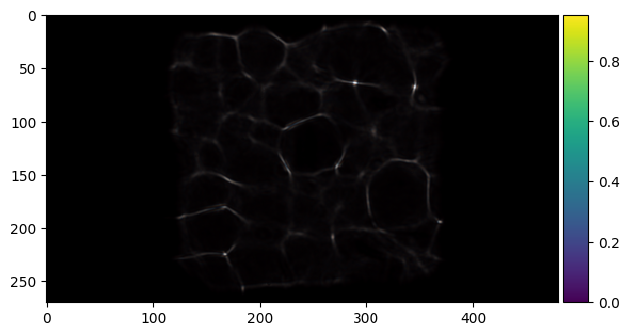

[(<Axes: >, <Axes: >)]

In [15]:
myim(FFT.psf,colorbar=True,torch2np=True)

In [16]:
idl = iter(data.train_loader)

/home/nadavgeva/dev/venv/phoco/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [17]:
batch = next(idl)

In [18]:
source, target, filename = batch

In [19]:
source.shape,target.shape

(torch.Size([1, 3, 270, 480]), torch.Size([1, 3, 270, 480]))

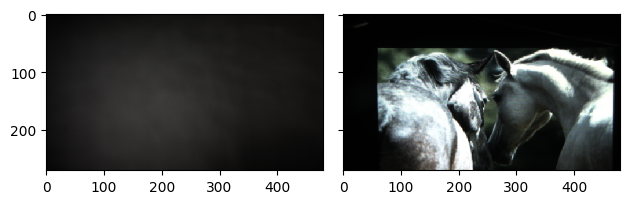

[(<Axes: >, None), (<Axes: >, None)]

In [20]:
myim(source[0]*0.5+0.5,target[0]*0.5+0.5,torch2np=True)

In [21]:
fft_output = FFT(source)

In [22]:
fft_output.shape

torch.Size([1, 3, 270, 480])

In [23]:
fft_output_vis = fft_output[0].mul(0.5).add(0.5)
                

In [24]:
fft_output_vis.shape

torch.Size([3, 270, 480])

In [25]:
fft_output_vis = (fft_output_vis - fft_output_vis.min()) / (
                                fft_output_vis.max() - fft_output_vis.min()
                            )

In [26]:
#cxhxw - > hxwxc 
#fft_output_vis = fft_output_vis.permute(1, 2, 0).cpu().detach().numpy()

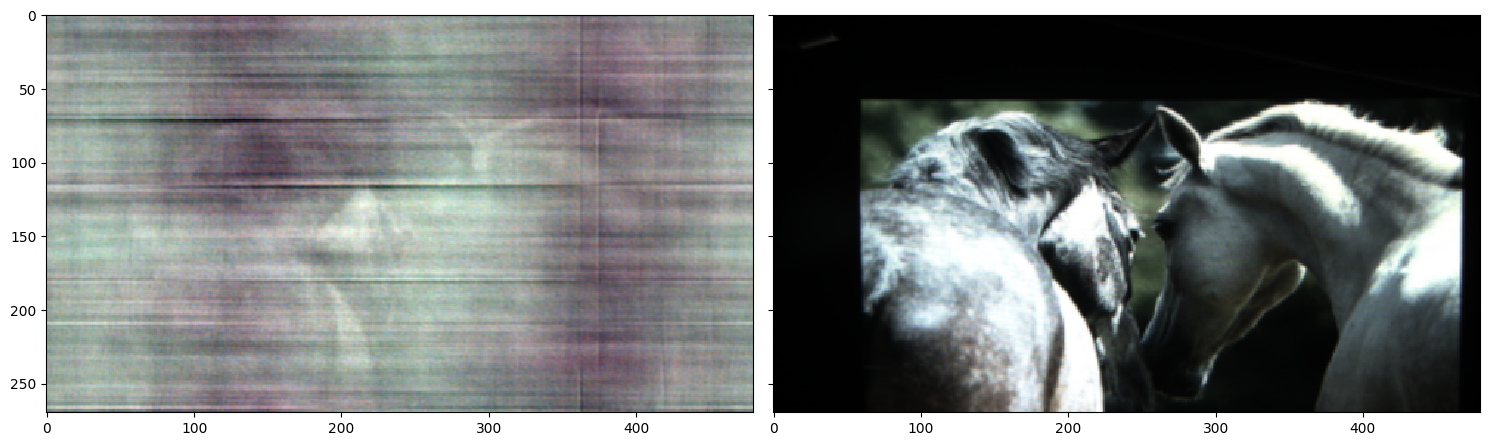

[(<Axes: >, None), (<Axes: >, None)]

In [27]:
myim(fft_output_vis.cpu().detach(),target[0]*0.5+0.5,
    torch2np=True,figsize=[15,30],)

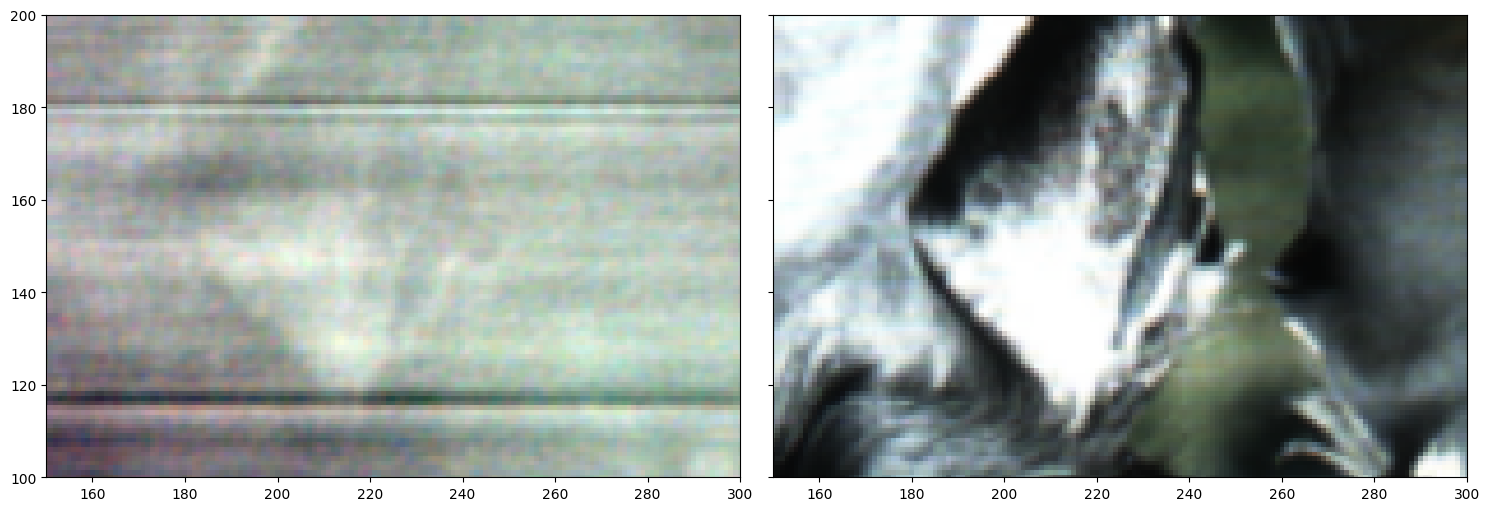

[(<Axes: >, None), (<Axes: >, None)]

In [29]:
myim(fft_output_vis.cpu().detach(),target[0]*0.5+0.5,
    torch2np=True,figsize=[15,30],x_lim=[150,300],y_lim=[100,200])

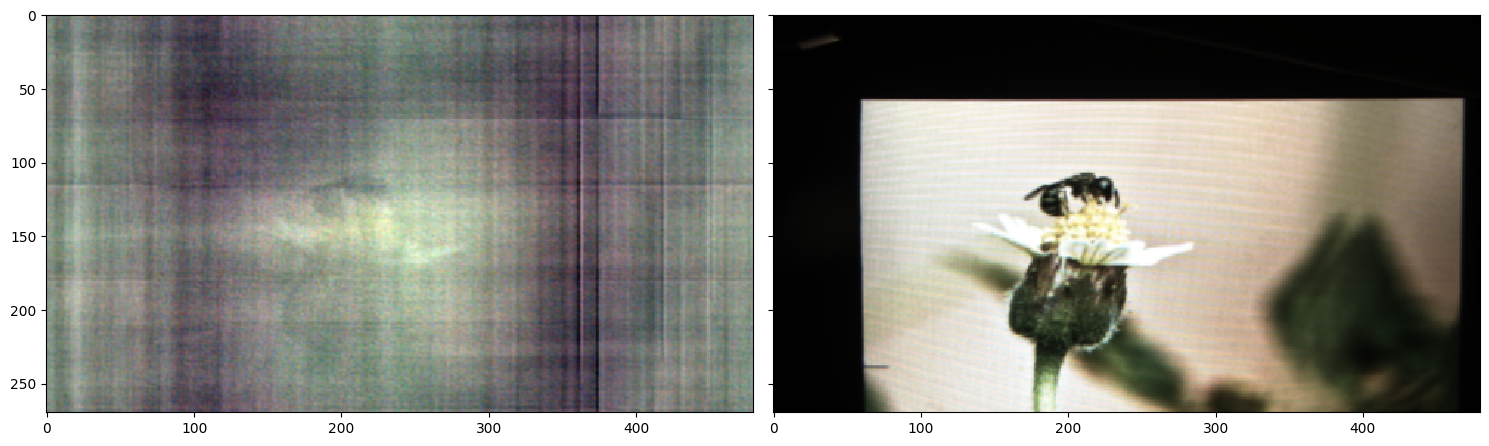

[(<Axes: >, None), (<Axes: >, None)]

In [ ]:
myim(fft_output_vis.cpu().detach(),target[0]*0.5+0.5,
    torch2np=True,figsize=[15,30],)

In [30]:
#plt.imshow(fft_output_vis)

In [31]:
FFT.wiener_crop.shape

torch.Size([3, 270, 480])

WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0011586925..0.003256618].


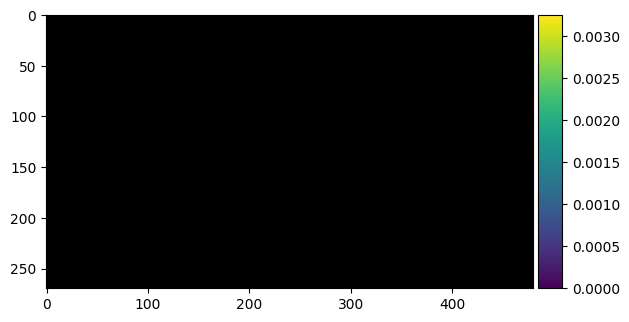

[(<Axes: >, <Axes: >)]

In [ ]:
psf = FFT.wiener_crop.detach().cpu()#.numpy()
myim(psf,colorbar=True,torch2np=True,)#global_range=[0,0.1])

In [40]:
args.psf_mat

PosixPath('/mnt/c/dev/lensless/diffuser_data/psf.tiff')

In [54]:
#psf = load_psf(args.psf_mat)
psf  = np.array(Image.open(args.psf_mat))

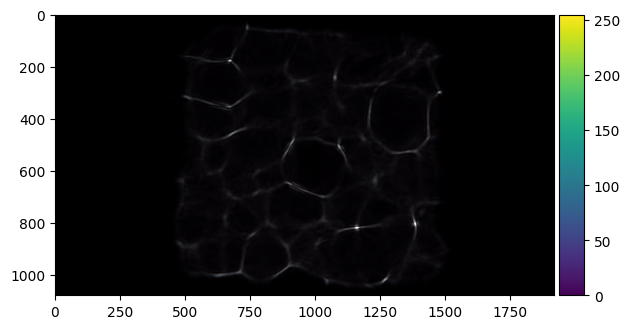

[(<Axes: >, <Axes: >)]

In [55]:
#plt.imshow(psf)
#myim(psf,colorbar=True,torch2np=True,global_range=[0,0.0000001])
myim(psf,colorbar=True,torch2np=False,global_range=[None,None])

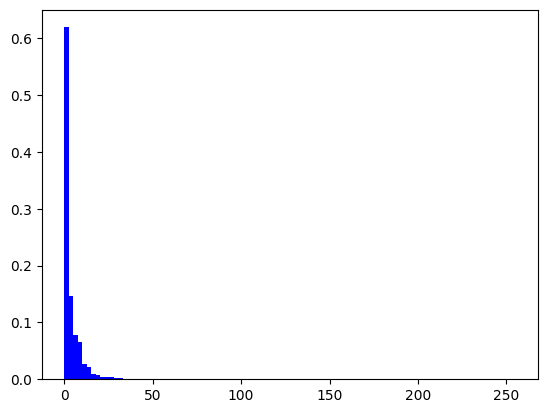

In [56]:
_=plot_hist(psf,bins=100,)#hrange=[0,0.15])


WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011725903..0.22811583].


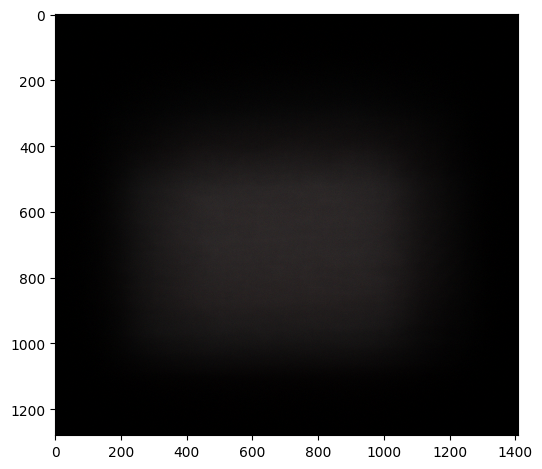

[(<Axes: >, None)]

In [63]:
myim(source[0,:3].detach()*0.5+0.5,torch2np=True)

In [20]:
meas_height = 1518  # original height of meas
meas_width = 2012  # original width of meas
meas_crop_size_x = 1280  # Meas crop. If 0, assume no crop
meas_crop_size_y = 1408
meas_centre_x = 808
meas_centre_y = 965

psf_height = 1280  # fft layer height
psf_width = 1408  # fft layer width
psf_crop_size_x = 1280
psf_crop_size_y = 1408
psf_centre_x = meas_centre_x
psf_centre_y = meas_centre_y

In [10]:
psf_mat = 'data/phase_psf/psf.npy'
psf_tiff = '/mnt/c/dev/lensless/diffuser_data/psf.tiff'

In [24]:
psf = np.array(np.load(psf_mat))
#psf = torch.tensor(np.load(args.psf_mat)).float()

psf_crop_top = psf_centre_x - psf_crop_size_x // 2
psf_crop_bottom = psf_centre_x + psf_crop_size_x // 2
psf_crop_left = psf_centre_y - psf_crop_size_y // 2
psf_crop_right = psf_centre_y + psf_crop_size_y // 2

psf_crop = psf[psf_crop_top:psf_crop_bottom, psf_crop_left:psf_crop_right]

#wiener_crop = get_wiener_matrix(
#    psf_crop, Gamma=args.fft_gamma, centre_roll=False
#    )
psf_phat=psf_crop

In [26]:
psf.shape,psf_crop.shape

((1518, 2012), (1280, 1408))

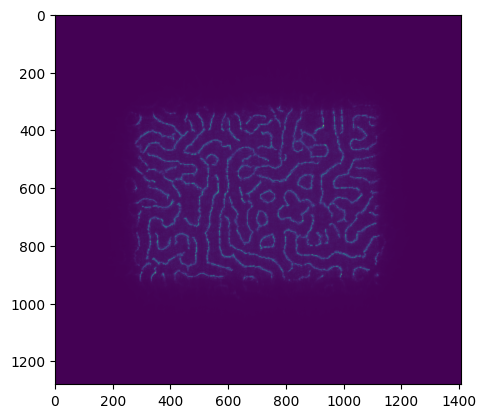

In [25]:
plt.imshow(psf_phat)

In [14]:
psf_pho = np.array(Image.open(psf_tiff))

In [15]:
psf.shape,psf.dtype

((1518, 2012), dtype('float32'))

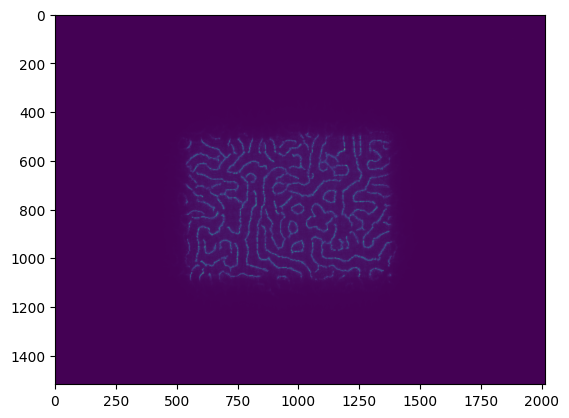

In [8]:
plt.imshow(psf)

In [ ]:
psf_phat.max(),psf_phat.min(),

(np.float32(1.0), np.float32(0.0))

In [16]:
psf_pho.shape,psf_pho.dtype

((1080, 1920, 3), dtype('uint8'))

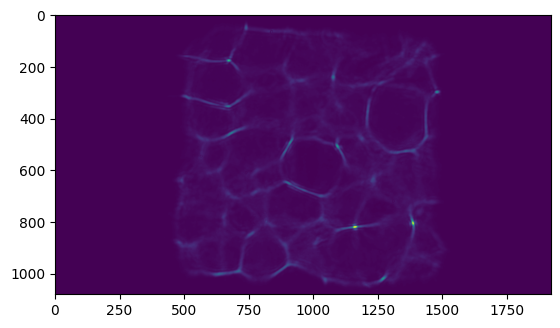

In [19]:
plt.imshow(psf_pho[...,0])